In [ ]:
%pip install -r requirements.txt

In [68]:
import warnings
warnings.filterwarnings('ignore') # Usado para no mostrar advertencias durante la ejecución del código

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone # Usado para clonar un pipeline o modelo (en su estado no entrenado) 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.utils import resample

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


##  1. Carga y análisis de datos

### Breast Cancer

#### a) Carga el conjunto de datos

In [71]:
# wdbc := breast+cancer+wisconsin+diagnostic
wdbc_data = 'data/breast+cancer+wisconsin+diagnostic/wdbc.data'
wdbc_names = 'data/breast+cancer+wisconsin+diagnostic/wdbc.names'

feature_names = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry',
    'fractal_dimension'
]
wdbc_columns = ['id', 'diagnosis'] + [
    f'{stat}_{feature}'
    for stat in ['mean', 'se', 'worst']
    for feature in feature_names
]

wdbc_df = pd.read_csv(wdbc_data, header=None, names=wdbc_columns)
print('Dimensiones:', wdbc_df.shape)
wdbc_df.head()


Dimensiones: (569, 32)


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### b) Visualización de la distribución de las clases

,frecuencia
diagnosis,
B,357
M,212


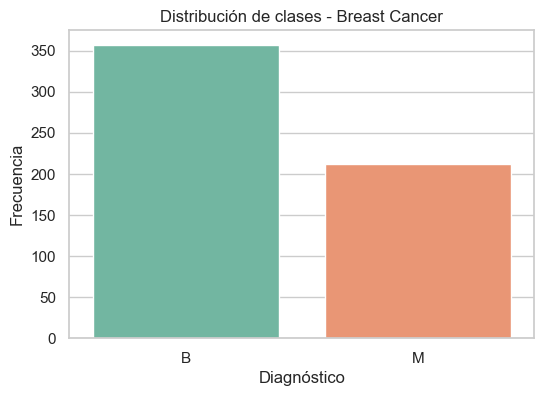

In [70]:
# Distribución de clases: Breast Cancer
wdbc_class_counts = wdbc_df['diagnosis'].value_counts().sort_index()
display(wdbc_class_counts.to_frame('frecuencia'))

plt.figure(figsize=(6, 4))
sns.countplot(data=wdbc_df, x='diagnosis', order=wdbc_class_counts.index, palette='Set2')
plt.title('Distribución de clases - Breast Cancer')
plt.xlabel('Diagnóstico')
plt.ylabel('Frecuencia')
plt.show()


#### c) Análisis de valores faltantes (porcentaje de valores faltantes por columna)

In [24]:
# Porcentaje de valores faltantes: Breast Cancer
wdbc_missing = (wdbc_df.isna().mean() * 100).sort_values(ascending=False)
display(wdbc_missing.to_frame('porcentaje_faltantes').head(10))
print('Total de valores faltantes:', int(wdbc_df.isna().sum().sum()))


,porcentaje_faltantes
id,0.0
diagnosis,0.0
worst_symmetry,0.0
worst_concave_points,0.0
worst_concavity,0.0
worst_compactness,0.0
worst_smoothness,0.0
worst_area,0.0
worst_perimeter,0.0
worst_texture,0.0


Total de valores faltantes: 0


### Parkison

#### a) Carga el conjunto de datos

In [73]:
# parkinsons_updrs := parkinsons+telemonitoring
parkinsons_updrs_data = 'data/parkinsons+telemonitoring/parkinsons_updrs.data'
parkinsons_updrs_names = 'data/parkinsons+telemonitoring/parkinsons_updrs.names'

parkinsons_updrs_df = pd.read_csv(parkinsons_updrs_data)
print('Dimensiones:', parkinsons_updrs_df.shape)
parkinsons_updrs_df.head()


Dimensiones: (5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


#### b) Visualización de la distribución de las clases

,frecuencia
updrs_severity,
low,1961
medium,1956
high,1958


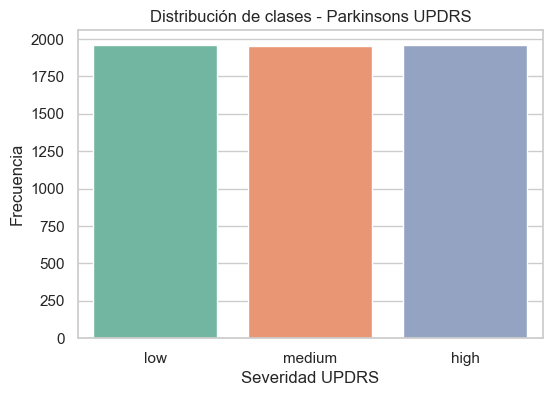

In [26]:
# Distribución de clases: Parkinsons
# Este dataset es originalmente de regresión. Para aplicar clasificadores, se crea
# una clase de severidad con terciles de total_UPDRS.
parkinsons_updrs_df = parkinsons_updrs_df.copy()
parkinsons_updrs_df['updrs_severity'] = pd.qcut(
    parkinsons_updrs_df['total_UPDRS'],
    q=3,
    labels=['low', 'medium', 'high']
)

parkinsons_class_counts = parkinsons_updrs_df['updrs_severity'].value_counts().reindex(['low', 'medium', 'high'])
display(parkinsons_class_counts.to_frame('frecuencia'))

plt.figure(figsize=(6, 4))
sns.countplot(data=parkinsons_updrs_df, x='updrs_severity', order=['low', 'medium', 'high'], palette='Set2')
plt.title('Distribución de clases - Parkinsons UPDRS')
plt.xlabel('Severidad UPDRS')
plt.ylabel('Frecuencia')
plt.show()


#### c) Análisis de valores faltantes (porcentaje de valores faltantes por columna)

In [27]:
# Porcentaje de valores faltantes: Parkinsons
parkinsons_missing = (parkinsons_updrs_df.isna().mean() * 100).sort_values(ascending=False)
display(parkinsons_missing.to_frame('porcentaje_faltantes').head(10))
print('Total de valores faltantes:', int(parkinsons_updrs_df.isna().sum().sum()))


,porcentaje_faltantes
subject#,0.0
Shimmer(dB),0.0
PPE,0.0
DFA,0.0
RPDE,0.0
HNR,0.0
NHR,0.0
Shimmer:DDA,0.0
Shimmer:APQ11,0.0
Shimmer:APQ5,0.0


Total de valores faltantes: 0


## 2. Preprocesamiento y limpieza

### Breast Cancer

#### a) Separación de tipos de variables (Identificamos columnas numéricas y categóricas)

In [28]:
# Tipos de variables: Breast Cancer
wdbc_target = 'diagnosis'
wdbc_id_columns = ['id']
wdbc_numeric_features = wdbc_df.drop(columns=wdbc_id_columns + [wdbc_target]).select_dtypes(include='number').columns.tolist()
wdbc_categorical_features = wdbc_df.drop(columns=wdbc_id_columns + [wdbc_target]).select_dtypes(exclude='number').columns.tolist()

print('Columnas numéricas:', len(wdbc_numeric_features))
print(wdbc_numeric_features)
print('Columnas categóricas:', wdbc_categorical_features)


Columnas numéricas: 30
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'se_radius', 'se_texture', 'se_perimeter', 'se_area', 'se_smoothness', 'se_compactness', 'se_concavity', 'se_concave_points', 'se_symmetry', 'se_fractal_dimension', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']
Columnas categóricas: []


#### b) Verificar y aplicar limpieza de datos (faltantes, outliers, caracteres invalidos, etc.)

In [29]:
# Limpieza de datos: Breast Cancer
wdbc_clean = wdbc_df.copy()
wdbc_clean['diagnosis'] = wdbc_clean['diagnosis'].str.strip().str.upper()

for column in wdbc_numeric_features:
    wdbc_clean[column] = wdbc_clean[column].fillna(wdbc_clean[column].median())

wdbc_outlier_counts = {}
for column in wdbc_numeric_features:
    q1, q3 = wdbc_clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    wdbc_outlier_counts[column] = ((wdbc_clean[column] < lower) | (wdbc_clean[column] > upper)).sum()

display(pd.Series(wdbc_outlier_counts, name='outliers_iqr').sort_values(ascending=False).head(10))
print('Faltantes después de limpieza:', int(wdbc_clean.isna().sum().sum()))


se_area                    65
se_radius                  38
se_perimeter               38
worst_area                 35
se_smoothness              30
se_compactness             28
se_fractal_dimension       28
se_symmetry                27
mean_area                  25
worst_fractal_dimension    24
Name: outliers_iqr, dtype: int64

Faltantes después de limpieza: 0


#### c) Estandarización de características (escaladores)

In [30]:
# Estandarización de características: Breast Cancer
wdbc_scaler_preview = StandardScaler()
wdbc_scaled_preview = pd.DataFrame(
    wdbc_scaler_preview.fit_transform(wdbc_clean[wdbc_numeric_features]),
    columns=wdbc_numeric_features
)
display(wdbc_scaled_preview.describe().loc[['mean', 'std']].round(3))


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


#### d) Separación en 70% entrenamiento y 30% prueba

In [31]:
# Separación 70% entrenamiento y 30% prueba: Breast Cancer
wdbc_X = wdbc_clean[wdbc_numeric_features]
wdbc_y = wdbc_clean[wdbc_target]

wdbc_X_train, wdbc_X_test, wdbc_y_train, wdbc_y_test = train_test_split(
    wdbc_X,
    wdbc_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=wdbc_y
)

print('Entrenamiento:', wdbc_X_train.shape)
print('Prueba:', wdbc_X_test.shape)
display(wdbc_y_train.value_counts().to_frame('train_count'))


Entrenamiento: (398, 30)
Prueba: (171, 30)


,train_count
diagnosis,
B,250
M,148


#### e) Manejo de desbalance de clases sobre el conjunto de entrenamiento (por ejemmplo SMOTE, ADASYN o sobre-muestreo aleatorio)

In [32]:
# Balanceo de clases por sobre-muestreo aleatorio: Breast Cancer
def random_oversample(X, y, random_state=RANDOM_STATE):
    data = X.copy()
    data['_target'] = y.to_numpy()
    max_count = data['_target'].value_counts().max()
    groups = []

    for label, group in data.groupby('_target'):
        groups.append(resample(group, replace=True, n_samples=max_count, random_state=random_state))

    balanced = pd.concat(groups).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns='_target'), balanced['_target']

wdbc_X_train_balanced, wdbc_y_train_balanced = random_oversample(wdbc_X_train, wdbc_y_train)
display(pd.DataFrame({
    'original': wdbc_y_train.value_counts(),
    'balanceado': wdbc_y_train_balanced.value_counts()
}).fillna(0).astype(int))


,original,balanceado
B,250,250
M,148,250


### Parkison

#### a) Separación de tipos de variables (Identificamos columnas numéricas y categóricas)

In [33]:
# Tipos de variables: Parkinsons
parkinsons_target = 'updrs_severity'
parkinsons_regression_targets = ['motor_UPDRS', 'total_UPDRS']
parkinsons_id_columns = ['subject#']
parkinsons_numeric_features = parkinsons_updrs_df.drop(
    columns=parkinsons_id_columns + parkinsons_regression_targets + [parkinsons_target]
).select_dtypes(include='number').columns.tolist()
parkinsons_categorical_features = parkinsons_updrs_df.drop(
    columns=parkinsons_id_columns + parkinsons_regression_targets + [parkinsons_target]
).select_dtypes(exclude='number').columns.tolist()

print('Columnas numéricas:', len(parkinsons_numeric_features))
print(parkinsons_numeric_features)
print('Columnas categóricas:', parkinsons_categorical_features)


Columnas numéricas: 19
['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
Columnas categóricas: []


#### b) Verificar y aplicar limpieza de datos (faltantes, outliers, caracteres invalidos, etc.)

In [34]:
# Limpieza de datos: Parkinsons
parkinsons_clean = parkinsons_updrs_df.copy()
parkinsons_clean['updrs_severity'] = parkinsons_clean['updrs_severity'].astype(str)

for column in parkinsons_numeric_features:
    parkinsons_clean[column] = parkinsons_clean[column].fillna(parkinsons_clean[column].median())

parkinsons_outlier_counts = {}
for column in parkinsons_numeric_features:
    q1, q3 = parkinsons_clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    parkinsons_outlier_counts[column] = ((parkinsons_clean[column] < lower) | (parkinsons_clean[column] > upper)).sum()

display(pd.Series(parkinsons_outlier_counts, name='outliers_iqr').sort_values(ascending=False).head(10))
print('Faltantes después de limpieza:', int(parkinsons_clean.isna().sum().sum()))


NHR             436
Jitter:PPQ5     425
Jitter:RAP      414
Jitter:DDP      413
Jitter(%)       398
Jitter(Abs)     366
Shimmer         333
Shimmer(dB)     332
Shimmer:APQ3    332
Shimmer:DDA     331
Name: outliers_iqr, dtype: int64

Faltantes después de limpieza: 0


#### c) Estandarización de características (escaladores)

In [35]:
# Estandarización de características: Parkinsons
parkinsons_scaler_preview = StandardScaler()
parkinsons_scaled_preview = pd.DataFrame(
    parkinsons_scaler_preview.fit_transform(parkinsons_clean[parkinsons_numeric_features]),
    columns=parkinsons_numeric_features
)
display(parkinsons_scaled_preview.describe().loc[['mean', 'std']].round(3))


,age,sex,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
mean,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


#### d) Separación en 70% entrenamiento y 30% prueba

In [36]:
# Separación 70% entrenamiento y 30% prueba: Parkinsons
parkinsons_X = parkinsons_clean[parkinsons_numeric_features]
parkinsons_y = parkinsons_clean[parkinsons_target]

parkinsons_X_train, parkinsons_X_test, parkinsons_y_train, parkinsons_y_test = train_test_split(
    parkinsons_X,
    parkinsons_y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=parkinsons_y
)

print('Entrenamiento:', parkinsons_X_train.shape)
print('Prueba:', parkinsons_X_test.shape)
display(parkinsons_y_train.value_counts().to_frame('train_count'))


Entrenamiento: (4112, 19)
Prueba: (1763, 19)


,train_count
updrs_severity,
low,1373
high,1370
medium,1369


#### e) Manejo de desbalance de clases sobre el conjunto de entrenamiento (por ejemmplo SMOTE, ADASYN o sobre-muestreo aleatorio)

In [37]:
# Balanceo de clases por sobre-muestreo aleatorio: Parkinsons
parkinsons_X_train_balanced, parkinsons_y_train_balanced = random_oversample(
    parkinsons_X_train,
    parkinsons_y_train
)
display(pd.DataFrame({
    'original': parkinsons_y_train.value_counts(),
    'balanceado': parkinsons_y_train_balanced.value_counts()
}).fillna(0).astype(int))


,original,balanceado
high,1370,1373
low,1373,1373
medium,1369,1373


## 3. Reducción de dimensionalidad por análisis de componentes principales (PCA)

### Breast Cancer

#### a) Aplicar PCA a los datos balanceados

In [38]:
# Aplicar PCA a los datos balanceados: Breast Cancer
wdbc_pca_scaler = StandardScaler()
wdbc_X_train_balanced_scaled = wdbc_pca_scaler.fit_transform(wdbc_X_train_balanced)
wdbc_X_test_scaled = wdbc_pca_scaler.transform(wdbc_X_test)

wdbc_pca = PCA(random_state=RANDOM_STATE)
wdbc_X_train_pca = wdbc_pca.fit_transform(wdbc_X_train_balanced_scaled)
wdbc_X_test_pca = wdbc_pca.transform(wdbc_X_test_scaled)
print('Componentes calculados:', wdbc_pca.n_components_)


Componentes calculados: 30


#### b) Cálculo de la varianza acumulada

In [39]:
# Varianza acumulada: Breast Cancer
wdbc_cumulative_variance = np.cumsum(wdbc_pca.explained_variance_ratio_)
wdbc_variance_table = pd.DataFrame({
    'component': np.arange(1, len(wdbc_cumulative_variance) + 1),
    'explained_variance': wdbc_pca.explained_variance_ratio_,
    'cumulative_variance': wdbc_cumulative_variance
})
display(wdbc_variance_table.head(10))


,component,explained_variance,cumulative_variance
0,1,0.431775,0.431775
1,2,0.200345,0.632119
2,3,0.094918,0.727038
3,4,0.064042,0.791080
4,5,0.054580,0.845660
5,6,0.043803,0.889463
6,7,0.022758,0.912221
7,8,0.016202,0.928423
8,9,0.012862,0.941284
9,10,0.011546,0.952830


#### c) Encontrar el número de componentes para el 95% de varianza

In [40]:
# Número de componentes para 95% de varianza: Breast Cancer
wdbc_n_components_95 = int(np.argmax(wdbc_cumulative_variance >= 0.95) + 1)
print(f'Componentes necesarios para 95% de varianza: {wdbc_n_components_95}')


Componentes necesarios para 95% de varianza: 10


#### d) Gráfico del números de componentes principales y varianza acumulada

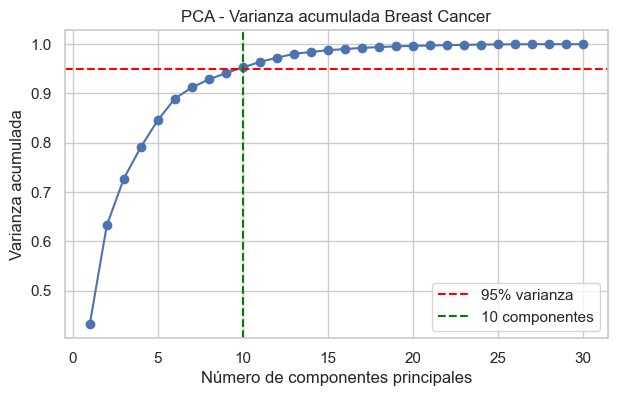

In [41]:
# Gráfico de componentes y varianza acumulada: Breast Cancer
plt.figure(figsize=(7, 4))
plt.plot(wdbc_variance_table['component'], wdbc_variance_table['cumulative_variance'], marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% varianza')
plt.axvline(wdbc_n_components_95, color='green', linestyle='--', label=f'{wdbc_n_components_95} componentes')
plt.title('PCA - Varianza acumulada Breast Cancer')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.show()


### Parkison

#### a) Aplicar PCA a los datos balanceados

In [42]:
# Aplicar PCA a los datos balanceados: Parkinsons
parkinsons_pca_scaler = StandardScaler()
parkinsons_X_train_balanced_scaled = parkinsons_pca_scaler.fit_transform(parkinsons_X_train_balanced)
parkinsons_X_test_scaled = parkinsons_pca_scaler.transform(parkinsons_X_test)

parkinsons_pca = PCA(random_state=RANDOM_STATE)
parkinsons_X_train_pca = parkinsons_pca.fit_transform(parkinsons_X_train_balanced_scaled)
parkinsons_X_test_pca = parkinsons_pca.transform(parkinsons_X_test_scaled)
print('Componentes calculados:', parkinsons_pca.n_components_)


Componentes calculados: 19


#### b) Cálculo de la varianza acumulada

In [43]:
# Varianza acumulada: Parkinsons
parkinsons_cumulative_variance = np.cumsum(parkinsons_pca.explained_variance_ratio_)
parkinsons_variance_table = pd.DataFrame({
    'component': np.arange(1, len(parkinsons_cumulative_variance) + 1),
    'explained_variance': parkinsons_pca.explained_variance_ratio_,
    'cumulative_variance': parkinsons_cumulative_variance
})
display(parkinsons_variance_table.head(10))


,component,explained_variance,cumulative_variance
0,1,0.597550,0.597550
1,2,0.089106,0.686656
2,3,0.080058,0.766713
3,4,0.053585,0.820298
4,5,0.052553,0.872851
5,6,0.040905,0.913756
6,7,0.035498,0.949254
7,8,0.014678,0.963931
8,9,0.010838,0.974770
9,10,0.009000,0.983769


#### c) Encontrar el número de componentes para el 95% de varianza

In [44]:
# Número de componentes para 95% de varianza: Parkinsons
parkinsons_n_components_95 = int(np.argmax(parkinsons_cumulative_variance >= 0.95) + 1)
print(f'Componentes necesarios para 95% de varianza: {parkinsons_n_components_95}')


Componentes necesarios para 95% de varianza: 8


#### d) Gráfico del números de componentes principales y varianza acumulada

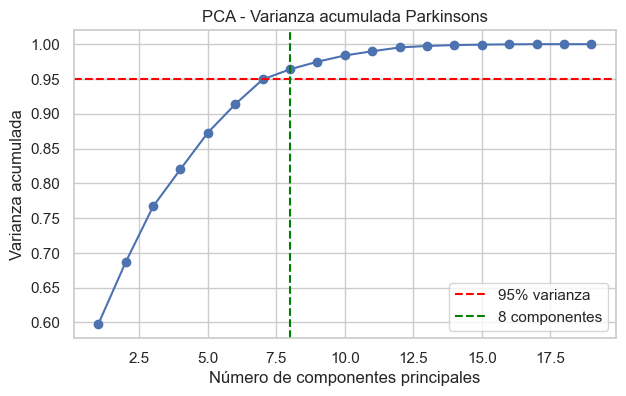

In [45]:
# Gráfico de componentes y varianza acumulada: Parkinsons
plt.figure(figsize=(7, 4))
plt.plot(parkinsons_variance_table['component'], parkinsons_variance_table['cumulative_variance'], marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% varianza')
plt.axvline(parkinsons_n_components_95, color='green', linestyle='--', label=f'{parkinsons_n_components_95} componentes')
plt.title('PCA - Varianza acumulada Parkinsons')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.show()


## 4. Definición de modelos, esquema de trabajo y búsqueda en cuadrícula (grid search)

### Breast Cancer

#### a) Desarrollar un esquema de funciones (pipelines ) que integren el pre-procesamiento y el clasificador.

In [46]:
# Pipelines de preprocesamiento y clasificación: Breast Cancer
wdbc_pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=wdbc_n_components_95, random_state=RANDOM_STATE)),
        ('model', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=wdbc_n_components_95, random_state=RANDOM_STATE)),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=wdbc_n_components_95, random_state=RANDOM_STATE)),
        ('model', SVC(random_state=RANDOM_STATE))
    ])
}
list(wdbc_pipelines.keys())


['KNN', 'Decision Tree', 'SVM']

#### b) La búsqueda en cuadrícula nos permitirá encontrar los mejores hiper-parámetros. Este método consiste en especificar una lista de posibles valores para cada hiperparámetro y luego entrenar el modelo para cada combinación de estos valores. Se evalúa el rendimiento de cada modelo y se selecciona la combinación de hiperparámetros que da el mejor rendimiento. Este método es exhaustivo y puede resultar computacionalmente costoso, especialmente cuando se trata con un gran número de hiperparámetros o un gran número de datos.

In [47]:
# Función para búsqueda en cuadrícula
def run_grid_searches(pipelines, param_grids, X_train, y_train, cv=3):
    searches = {}
    for model_name, pipeline in pipelines.items():
        print(f'Entrenando {model_name}...')
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring='accuracy',
            cv=cv,
            n_jobs=1,
            refit=True,
            return_train_score=True
        )
        search.fit(X_train, y_train)
        searches[model_name] = search
        print(f'  Mejor accuracy CV: {search.best_score_:.4f}')
        print(f'  Mejores parámetros: {search.best_params_}')
    return searches

print('Función run_grid_searches lista.')


Función run_grid_searches lista.


### Parkison

#### a) Desarrollar un esquema de funciones (pipelines ) que integren el pre-procesamiento y el clasificador.

In [48]:
# Pipelines de preprocesamiento y clasificación: Parkinsons
parkinsons_pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=parkinsons_n_components_95, random_state=RANDOM_STATE)),
        ('model', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=parkinsons_n_components_95, random_state=RANDOM_STATE)),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=parkinsons_n_components_95, random_state=RANDOM_STATE)),
        ('model', SVC(random_state=RANDOM_STATE))
    ])
}
list(parkinsons_pipelines.keys())


['KNN', 'Decision Tree', 'SVM']

#### b) La búsqueda en cuadrícula nos permitirá encontrar los mejores hiper-parámetros. Este método consiste en especificar una lista de posibles valores para cada hiperparámetro y luego entrenar el modelo para cada combinación de estos valores. Se evalúa el rendimiento de cada modelo y se selecciona la combinación de hiperparámetros que da el mejor rendimiento. Este método es exhaustivo y puede resultar computacionalmente costoso, especialmente cuando se trata con un gran número de hiperparámetros o un gran número de datos.

In [49]:
# La misma función run_grid_searches se usa para Parkinsons.
print('Función run_grid_searches disponible:', callable(run_grid_searches))


Función run_grid_searches disponible: True


## 5. Configuración de modelos y cuadro de hiperparámetros

### Breast Cancer

#### a) Modelo de KNN

- vecinos (1,3,5,7,9)
- pesos (weights: ['uniform', 'distance'])
- distancia (metric:['euclidian', 'manhattan'])

In [50]:
# Hiperparámetros KNN: Breast Cancer
wdbc_knn_grid = {
    'model__n_neighbors': [1, 3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
wdbc_knn_grid


{'model__n_neighbors': [1, 3, 5, 7, 9],
 'model__weights': ['uniform', 'distance'],
 'model__metric': ['euclidean', 'manhattan']}

#### b) Modelo de árbol de decisión

- profundidad ([3, 5, 7, None])
- número mínimo de muestras por división (sample split: [2, 5, 10])
- criterio de división (criterion: ['gini', 'entropy])

In [51]:
# Hiperparámetros árbol de decisión: Breast Cancer
wdbc_tree_grid = {
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion': ['gini', 'entropy']
}
wdbc_tree_grid


{'model__max_depth': [3, 5, 7, None],
 'model__min_samples_split': [2, 5, 10],
 'model__criterion': ['gini', 'entropy']}

#### c) Modelo de SVM 

- Kernel (['linear', 'rbf'])
- Regularización C (0.1, 1, 10)
- Gamma ([’scale’, ’auto’, 0.01, 0.1])

In [52]:
# Hiperparámetros SVM y grid completo: Breast Cancer
wdbc_svm_grid = {
    'model__kernel': ['linear', 'rbf'],
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto', 0.01, 0.1]
}

wdbc_param_grids = {
    'KNN': wdbc_knn_grid,
    'Decision Tree': wdbc_tree_grid,
    'SVM': wdbc_svm_grid
}
wdbc_param_grids


{'KNN': {'model__n_neighbors': [1, 3, 5, 7, 9],
  'model__weights': ['uniform', 'distance'],
  'model__metric': ['euclidean', 'manhattan']},
 'Decision Tree': {'model__max_depth': [3, 5, 7, None],
  'model__min_samples_split': [2, 5, 10],
  'model__criterion': ['gini', 'entropy']},
 'SVM': {'model__kernel': ['linear', 'rbf'],
  'model__C': [0.1, 1, 10],
  'model__gamma': ['scale', 'auto', 0.01, 0.1]}}

### Parkison

#### a) Modelo de KNN

- vecinos (1,3,5,7,9)
- pesos (weights: ['uniform', 'distance'])
- distancia (metric:['euclidian', 'manhattan'])

In [53]:
# Hiperparámetros KNN: Parkinsons
parkinsons_knn_grid = {
    'model__n_neighbors': [1, 3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
parkinsons_knn_grid


{'model__n_neighbors': [1, 3, 5, 7, 9],
 'model__weights': ['uniform', 'distance'],
 'model__metric': ['euclidean', 'manhattan']}

#### b) Modelo de árbol de decisión

- profundidad ([3, 5, 7, None])
- número mínimo de muestras por división (sample split: [2, 5, 10])
- criterio de división (criterion: ['gini', 'entropy])

In [54]:
# Hiperparámetros árbol de decisión: Parkinsons
parkinsons_tree_grid = {
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion': ['gini', 'entropy']
}
parkinsons_tree_grid


{'model__max_depth': [3, 5, 7, None],
 'model__min_samples_split': [2, 5, 10],
 'model__criterion': ['gini', 'entropy']}

#### c) Modelo de SVM 

- Kernel (['linear', 'rbf'])
- Regularización C (0.1, 1, 10)
- Gamma ([’scale’, ’auto’, 0.01, 0.1])

In [55]:
# Hiperparámetros SVM y grid completo: Parkinsons
parkinsons_svm_grid = {
    'model__kernel': ['linear', 'rbf'],
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto', 0.01, 0.1]
}

parkinsons_param_grids = {
    'KNN': parkinsons_knn_grid,
    'Decision Tree': parkinsons_tree_grid,
    'SVM': parkinsons_svm_grid
}
parkinsons_param_grids


{'KNN': {'model__n_neighbors': [1, 3, 5, 7, 9],
  'model__weights': ['uniform', 'distance'],
  'model__metric': ['euclidean', 'manhattan']},
 'Decision Tree': {'model__max_depth': [3, 5, 7, None],
  'model__min_samples_split': [2, 5, 10],
  'model__criterion': ['gini', 'entropy']},
 'SVM': {'model__kernel': ['linear', 'rbf'],
  'model__C': [0.1, 1, 10],
  'model__gamma': ['scale', 'auto', 0.01, 0.1]}}

## 6. Entrenamiento, evaluación y comparación de resultados

### Breast Cancer

#### a) Mejores métricas de rendimiento sobre conjunto de prueba por conjunto de datos

In [56]:
# Entrenamiento y métricas en prueba: Breast Cancer
wdbc_searches = run_grid_searches(
    wdbc_pipelines,
    wdbc_param_grids,
    wdbc_X_train_balanced,
    wdbc_y_train_balanced,
    cv=3
)

def evaluate_searches(searches, X_test, y_test):
    rows = []
    predictions = {}
    for model_name, search in searches.items():
        y_pred = search.predict(X_test)
        predictions[model_name] = y_pred
        rows.append({
            'model': model_name,
            'best_cv_accuracy': search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'test_recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'test_f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'best_params': search.best_params_
        })
    return pd.DataFrame(rows).sort_values('test_accuracy', ascending=False), predictions

wdbc_results, wdbc_predictions = evaluate_searches(wdbc_searches, wdbc_X_test, wdbc_y_test)
wdbc_best_model_name = wdbc_results.iloc[0]['model']
wdbc_best_search = wdbc_searches[wdbc_best_model_name]
display(wdbc_results)


Entrenando KNN...
  Mejor accuracy CV: 0.9900
  Mejores parámetros: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'distance'}
Entrenando Decision Tree...
  Mejor accuracy CV: 0.9700
  Mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 2}
Entrenando SVM...
  Mejor accuracy CV: 0.9760
  Mejores parámetros: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


,model,best_cv_accuracy,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,best_params
0,KNN,0.990008,0.964912,0.962544,0.962544,0.962544,"{'model__metric': 'euclidean', 'model__n_neigh..."
2,SVM,0.975988,0.959064,0.955080,0.957871,0.956436,"{'model__C': 10, 'model__gamma': 'auto', 'mode..."
1,Decision Tree,0.970012,0.912281,0.902502,0.920488,0.908670,"{'model__criterion': 'entropy', 'model__max_de..."


#### b) Matriz de decisión de los modelos entrenados con las mejores métricas

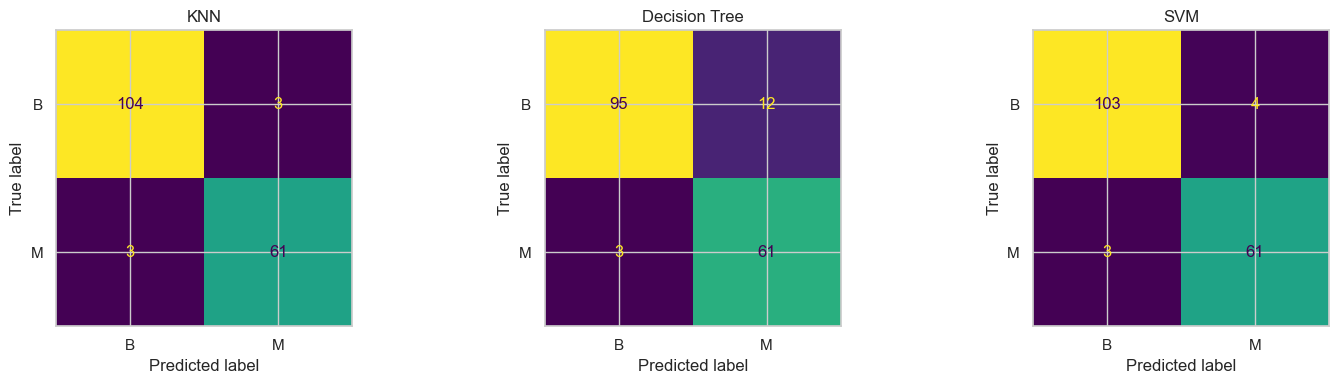

Mejor modelo: KNN
              precision    recall  f1-score   support

           B       0.97      0.97      0.97       107
           M       0.95      0.95      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [57]:
# Matrices de confusión: Breast Cancer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, y_pred) in zip(axes, wdbc_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(wdbc_y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

print('Mejor modelo:', wdbc_best_model_name)
print(classification_report(wdbc_y_test, wdbc_predictions[wdbc_best_model_name]))


#### c) Mostrar las fronteras de decisión superponiendo datos de entrenamiento y prueba

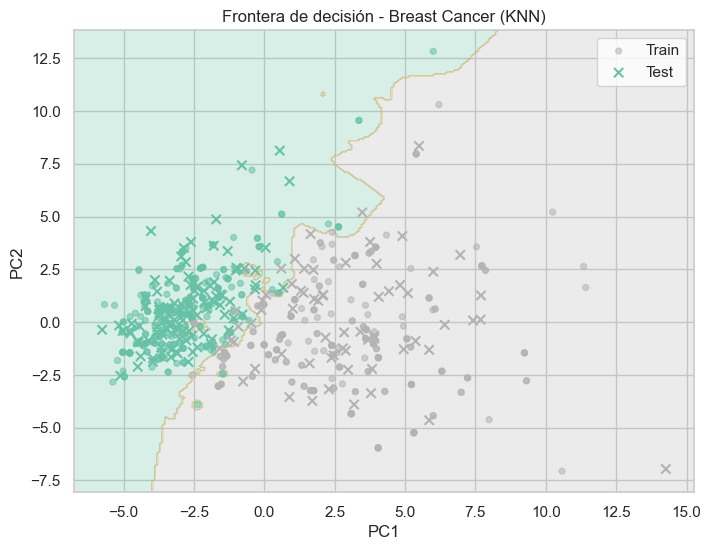

In [58]:
# Fronteras de decisión con 2 componentes PCA: Breast Cancer
def plot_decision_boundary_pca2(best_search, X_train, y_train, X_test, y_test, title):
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    pca2_pipeline = clone(best_search.best_estimator_)
    pca2_pipeline.set_params(pca__n_components=2)
    pca2_pipeline.fit(X_train, y_train_encoded)

    X_all = pd.concat([X_train, X_test], axis=0)
    X_all_2d = pca2_pipeline.named_steps['pca'].transform(
        pca2_pipeline.named_steps['scaler'].transform(X_all)
    )
    X_train_2d = X_all_2d[:len(X_train)]
    X_test_2d = X_all_2d[len(X_train):]

    x_min, x_max = X_all_2d[:, 0].min() - 1, X_all_2d[:, 0].max() + 1
    y_min, y_max = X_all_2d[:, 1].min() - 1, X_all_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    Z = pca2_pipeline.named_steps['model'].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='Set2')
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_encoded, cmap='Set2', s=18, alpha=0.55, label='Train')
    plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_encoded, cmap='Set2', s=45, edgecolor='black', marker='x', label='Test')
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()

plot_decision_boundary_pca2(
    wdbc_best_search,
    wdbc_X_train_balanced,
    wdbc_y_train_balanced,
    wdbc_X_test,
    wdbc_y_test,
    f'Frontera de decisión - Breast Cancer ({wdbc_best_model_name})'
)


#### d) Mostrar el árbol entrenado con los mejores parámetros

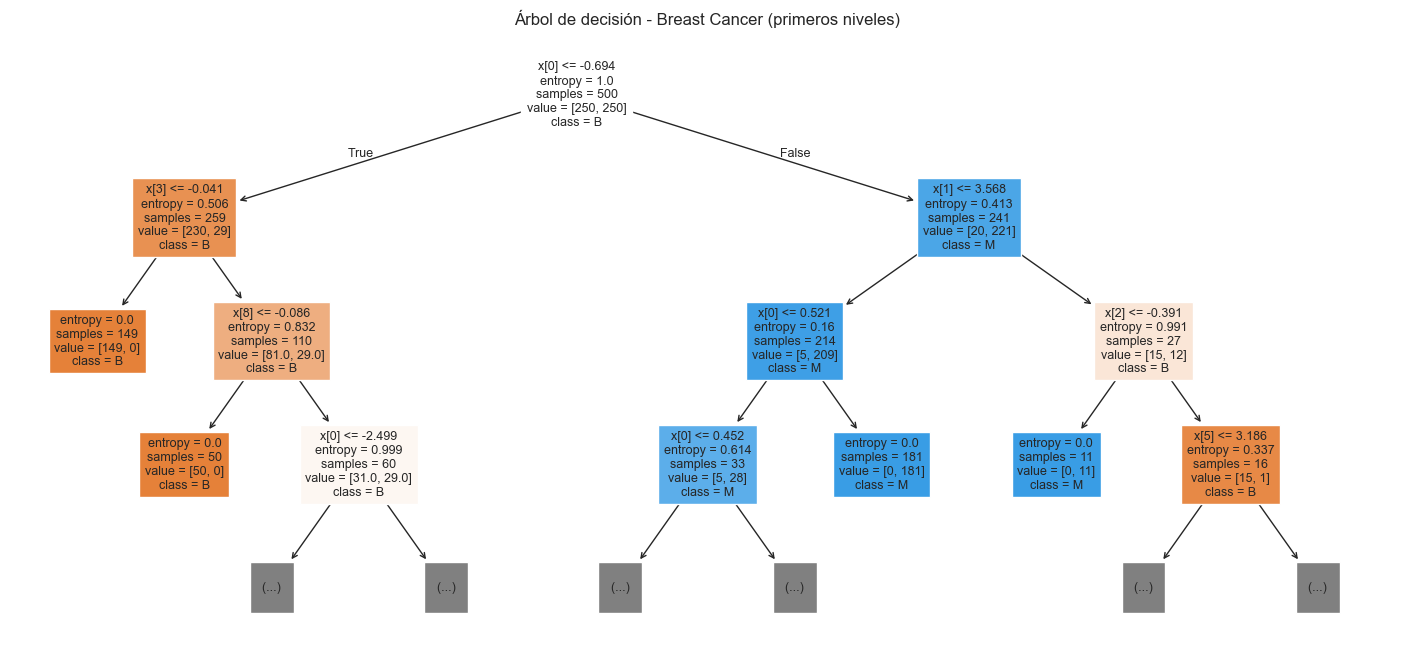

Mejores parámetros árbol: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 2}


In [59]:
# Árbol entrenado con mejores parámetros: Breast Cancer
wdbc_tree_best = wdbc_searches['Decision Tree'].best_estimator_
plt.figure(figsize=(18, 8))
plot_tree(
    wdbc_tree_best.named_steps['model'],
    filled=True,
    class_names=wdbc_tree_best.named_steps['model'].classes_,
    max_depth=3,
    fontsize=9
)
plt.title('Árbol de decisión - Breast Cancer (primeros niveles)')
plt.show()
print('Mejores parámetros árbol:', wdbc_searches['Decision Tree'].best_params_)


#### e) Comparar exactitud entre parámetros

,model,mean_test_score,std_test_score,rank_test_score,param_model__metric,param_model__n_neighbors,param_model__weights,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__C,param_model__gamma,param_model__kernel
35,Decision Tree,0.970012,0.004830,1,NaN,NaN,NaN,entropy,5,2.0,NaN,NaN,NaN
38,Decision Tree,0.970012,0.004830,1,NaN,NaN,NaN,entropy,7,2.0,NaN,NaN,NaN
41,Decision Tree,0.970012,0.004830,1,NaN,NaN,NaN,entropy,None,2.0,NaN,NaN,NaN
36,Decision Tree,0.968016,0.007417,4,NaN,NaN,NaN,entropy,5,5.0,NaN,NaN,NaN
37,Decision Tree,0.968016,0.007417,4,NaN,NaN,NaN,entropy,5,10.0,NaN,NaN,NaN
7,KNN,0.990008,0.005637,1,euclidean,7.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
9,KNN,0.987976,0.008536,2,euclidean,9.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
17,KNN,0.978008,0.005620,3,manhattan,7.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
5,KNN,0.975988,0.008511,4,euclidean,5.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
19,KNN,0.974004,0.002789,5,manhattan,9.0,distance,NaN,NaN,NaN,NaN,NaN,NaN


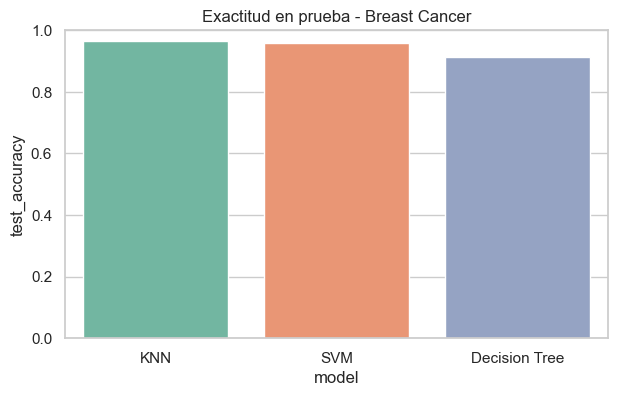

In [60]:
# Comparación de exactitud entre parámetros: Breast Cancer
def grid_results_table(searches):
    frames = []
    for model_name, search in searches.items():
        frame = pd.DataFrame(search.cv_results_)
        param_cols = [col for col in frame.columns if col.startswith('param_')]
        frame = frame[['mean_test_score', 'std_test_score', 'rank_test_score'] + param_cols].copy()
        frame.insert(0, 'model', model_name)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True).sort_values(['model', 'rank_test_score'])

wdbc_grid_results = grid_results_table(wdbc_searches)
display(wdbc_grid_results.groupby('model').head(5))

plt.figure(figsize=(7, 4))
sns.barplot(data=wdbc_results, x='model', y='test_accuracy', palette='Set2')
plt.ylim(0, 1)
plt.title('Exactitud en prueba - Breast Cancer')
plt.show()


#### f) ¿Qué hiperparámetro fue más relevante para cada conjunto de datos?

In [61]:
# Hiperparámetro más relevante: Breast Cancer
def hyperparameter_relevance(searches):
    rows = []
    for model_name, search in searches.items():
        results = pd.DataFrame(search.cv_results_)
        param_cols = [col for col in results.columns if col.startswith('param_')]
        for param in param_cols:
            grouped = results.groupby(param)['mean_test_score'].mean()
            rows.append({
                'model': model_name,
                'hyperparameter': param.replace('param_model__', ''),
                'score_range': grouped.max() - grouped.min(),
                'best_average_value': grouped.idxmax()
            })
    return pd.DataFrame(rows).sort_values(['model', 'score_range'], ascending=[True, False])

wdbc_hyperparameter_relevance = hyperparameter_relevance(wdbc_searches)
display(wdbc_hyperparameter_relevance)
print('Más relevante por modelo:')
display(wdbc_hyperparameter_relevance.groupby('model').head(1))


,model,hyperparameter,score_range,best_average_value
4,Decision Tree,max_depth,0.035038,7
3,Decision Tree,criterion,0.016449,entropy
5,Decision Tree,min_samples_split,0.005739,2
2,KNN,weights,0.024018,distance
1,KNN,n_neighbors,0.016500,1
0,KNN,metric,0.008387,euclidean
6,SVM,C,0.025004,10.0
8,SVM,kernel,0.010657,linear
7,SVM,gamma,0.004000,scale


Más relevante por modelo:


,model,hyperparameter,score_range,best_average_value
4,Decision Tree,max_depth,0.035038,7
2,KNN,weights,0.024018,distance
6,SVM,C,0.025004,10.0


### Parkison

#### a) Mejores métricas de rendimiento sobre conjunto de prueba por conjunto de datos

In [62]:
# Entrenamiento y métricas en prueba: Parkinsons
parkinsons_searches = run_grid_searches(
    parkinsons_pipelines,
    parkinsons_param_grids,
    parkinsons_X_train_balanced,
    parkinsons_y_train_balanced,
    cv=3
)

parkinsons_results, parkinsons_predictions = evaluate_searches(
    parkinsons_searches,
    parkinsons_X_test,
    parkinsons_y_test
)
parkinsons_best_model_name = parkinsons_results.iloc[0]['model']
parkinsons_best_search = parkinsons_searches[parkinsons_best_model_name]
display(parkinsons_results)


Entrenando KNN...
  Mejor accuracy CV: 0.8660
  Mejores parámetros: {'model__metric': 'euclidean', 'model__n_neighbors': 1, 'model__weights': 'uniform'}
Entrenando Decision Tree...
  Mejor accuracy CV: 0.8213
  Mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2}
Entrenando SVM...
  Mejor accuracy CV: 0.8082
  Mejores parámetros: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


,model,best_cv_accuracy,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,best_params
2,SVM,0.808206,0.774816,0.775670,0.774803,0.774853,"{'model__C': 10, 'model__gamma': 'auto', 'mode..."
0,KNN,0.865987,0.754963,0.754868,0.754954,0.754811,"{'model__metric': 'euclidean', 'model__n_neigh..."
1,Decision Tree,0.821316,0.669881,0.669661,0.669887,0.669718,"{'model__criterion': 'gini', 'model__max_depth..."


#### b) Matriz de decisión de los modelos entrenados con las mejores métricas

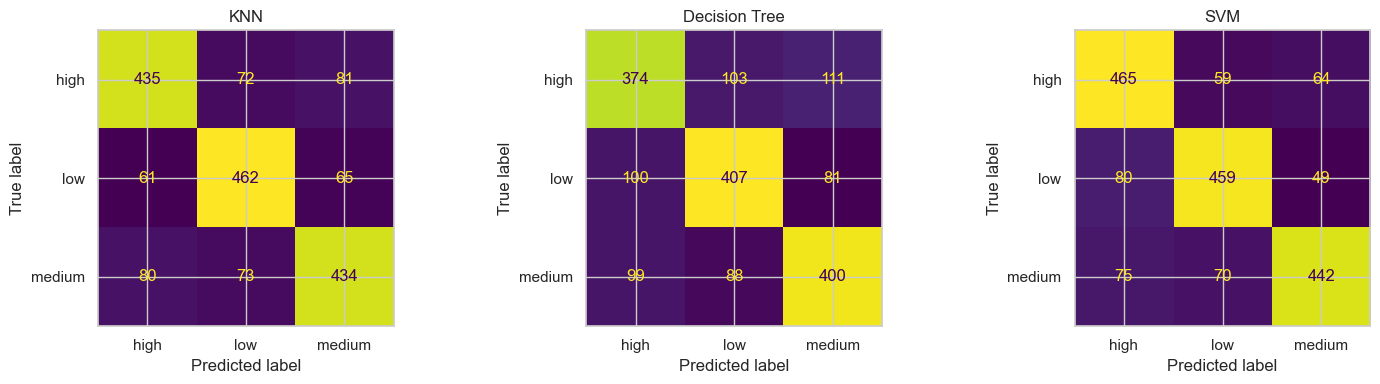

Mejor modelo: SVM
              precision    recall  f1-score   support

        high       0.75      0.79      0.77       588
         low       0.78      0.78      0.78       588
      medium       0.80      0.75      0.77       587

    accuracy                           0.77      1763
   macro avg       0.78      0.77      0.77      1763
weighted avg       0.78      0.77      0.77      1763



In [63]:
# Matrices de confusión: Parkinsons
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, y_pred) in zip(axes, parkinsons_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(parkinsons_y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(model_name)
plt.tight_layout()
plt.show()

print('Mejor modelo:', parkinsons_best_model_name)
print(classification_report(parkinsons_y_test, parkinsons_predictions[parkinsons_best_model_name]))


#### c) Mostrar las fronteras de decisión superponiendo datos de entrenamiento y prueba

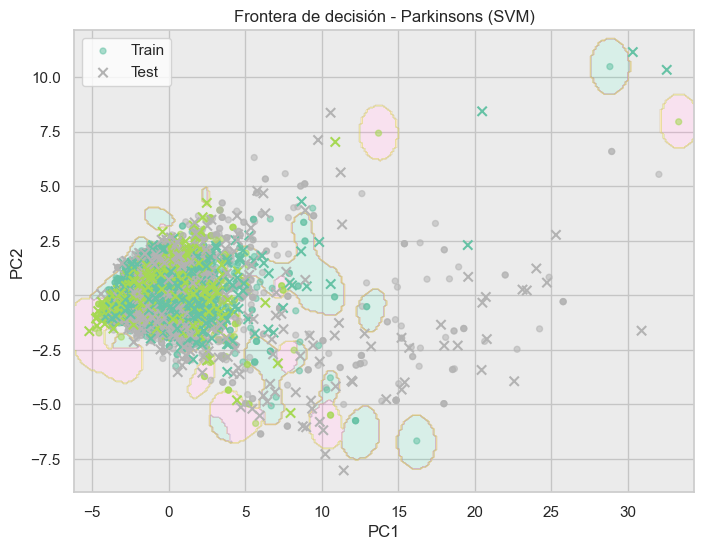

In [64]:
# Fronteras de decisión con 2 componentes PCA: Parkinsons
plot_decision_boundary_pca2(
    parkinsons_best_search,
    parkinsons_X_train_balanced,
    parkinsons_y_train_balanced,
    parkinsons_X_test,
    parkinsons_y_test,
    f'Frontera de decisión - Parkinsons ({parkinsons_best_model_name})'
)


#### d) Mostrar el árbol entrenado con los mejores parámetros

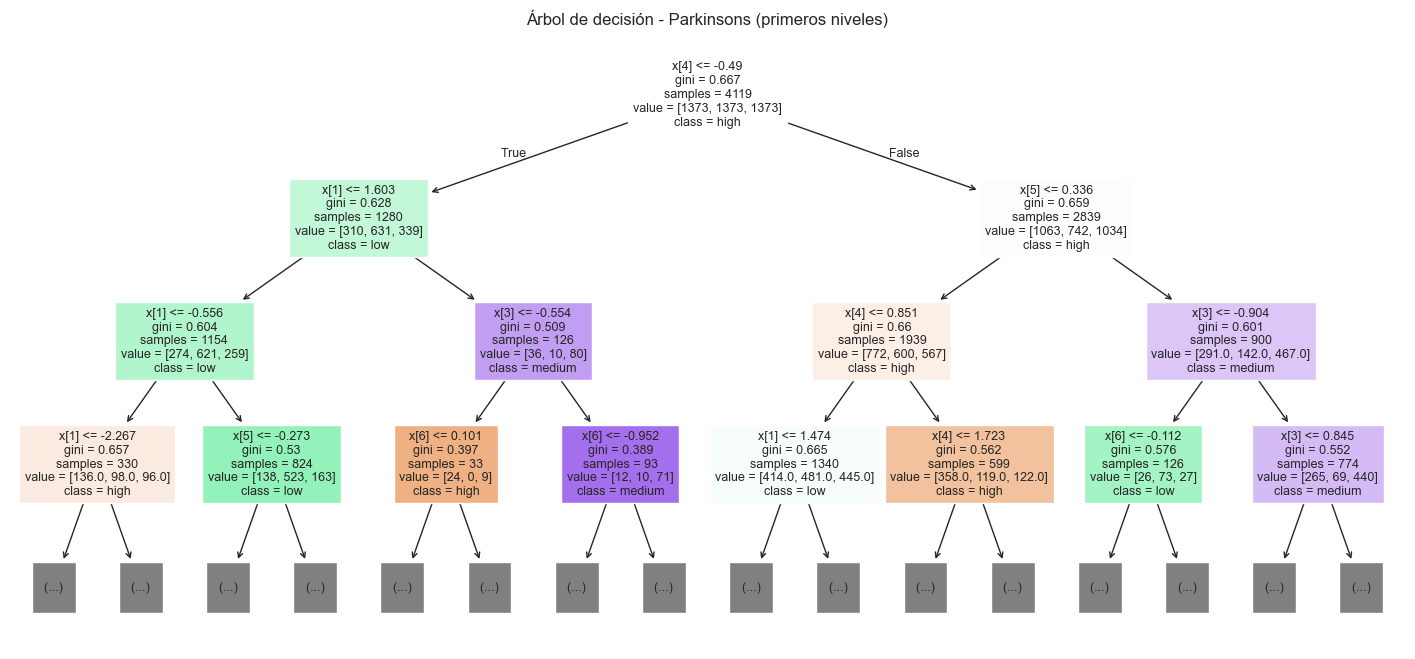

Mejores parámetros árbol: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2}


In [65]:
# Árbol entrenado con mejores parámetros: Parkinsons
parkinsons_tree_best = parkinsons_searches['Decision Tree'].best_estimator_
plt.figure(figsize=(18, 8))
plot_tree(
    parkinsons_tree_best.named_steps['model'],
    filled=True,
    class_names=parkinsons_tree_best.named_steps['model'].classes_,
    max_depth=3,
    fontsize=9
)
plt.title('Árbol de decisión - Parkinsons (primeros niveles)')
plt.show()
print('Mejores parámetros árbol:', parkinsons_searches['Decision Tree'].best_params_)


#### e) Comparar exactitud entre parámetros

,model,mean_test_score,std_test_score,rank_test_score,param_model__metric,param_model__n_neighbors,param_model__weights,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__C,param_model__gamma,param_model__kernel
29,Decision Tree,0.821316,0.014498,1,NaN,NaN,NaN,gini,None,2.0,NaN,NaN,NaN
41,Decision Tree,0.809420,0.004987,2,NaN,NaN,NaN,entropy,None,2.0,NaN,NaN,NaN
30,Decision Tree,0.804807,0.018890,3,NaN,NaN,NaN,gini,None,5.0,NaN,NaN,NaN
42,Decision Tree,0.789512,0.007776,4,NaN,NaN,NaN,entropy,None,5.0,NaN,NaN,NaN
31,Decision Tree,0.782471,0.017259,5,NaN,NaN,NaN,gini,None,10.0,NaN,NaN,NaN
0,KNN,0.865987,0.011879,1,euclidean,1.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN
1,KNN,0.865987,0.011879,1,euclidean,1.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
17,KNN,0.863802,0.007136,3,manhattan,7.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
19,KNN,0.863316,0.012207,4,manhattan,9.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
10,KNN,0.861860,0.007761,5,manhattan,1.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN


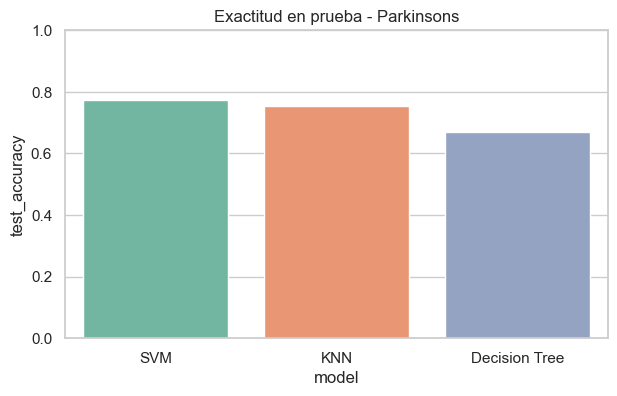

In [66]:
# Comparación de exactitud entre parámetros: Parkinsons
parkinsons_grid_results = grid_results_table(parkinsons_searches)
display(parkinsons_grid_results.groupby('model').head(5))

plt.figure(figsize=(7, 4))
sns.barplot(data=parkinsons_results, x='model', y='test_accuracy', palette='Set2')
plt.ylim(0, 1)
plt.title('Exactitud en prueba - Parkinsons')
plt.show()


#### f) ¿Qué hiperparámetro fue más relevante para cada conjunto de datos?

In [67]:
# Hiperparámetro más relevante: Parkinsons
parkinsons_hyperparameter_relevance = hyperparameter_relevance(parkinsons_searches)
display(parkinsons_hyperparameter_relevance)
print('Más relevante por modelo:')
display(parkinsons_hyperparameter_relevance.groupby('model').head(1))


,model,hyperparameter,score_range,best_average_value
4,Decision Tree,max_depth,0.134944,7
3,Decision Tree,criterion,0.019847,gini
5,Decision Tree,min_samples_split,0.010591,2
2,KNN,weights,0.067856,distance
1,KNN,n_neighbors,0.056506,1
0,KNN,metric,0.005171,manhattan
8,SVM,kernel,0.104738,rbf
6,SVM,C,0.082302,10.0
7,SVM,gamma,0.070972,auto


Más relevante por modelo:


,model,hyperparameter,score_range,best_average_value
4,Decision Tree,max_depth,0.134944,7
2,KNN,weights,0.067856,distance
8,SVM,kernel,0.104738,rbf


## Conclusiones